# 01a: Machine learning - iris classifier

In this notebook we build classifier models for the iris dataset.

The iris data contains three different classifications of iris species: setosa, versicolor, and virginica. We will build three classifier models, one to identify each species. For example, the versicolor model will identify whether or not a row of data is a versicolor iris: if the row isn't versicolor, the classifier does _not_ then work out whether it is setosa or virginica.

### AIM
* To load, inspect, and prepare iris dataset for supervised machine learning.
* To split the dataset into seperate training and texsting subsets to validate model generalisation.
* To train individual binary XGBoost classifiers for each species.
* To evaluate basic accuracy perfromance on both training and testing data.

### METHOD
1. Load the iris data via sklearn and structuring it into a pandas dataframe
2. Convert the column "species" into individual binry columns- "setosa", "versicolor", "virginica"
3. Divide the dataset into a training set (75%) and a testing set (25%).
4. Train a classifier made using xgboost on the training set. 
5. Compare predcited values against target lables to check accuracy on both subsets. (Accuracy is assessed via a utils file including all required formula codes).
6. Retrieve feature importance to understand which feature measures (septal/petal length/width) contributed most to the decision.

## Code setup

Import packages:

In [ ]:
from xgboost import XGBClassifier, plot_tree  # to make the classifier
from sklearn.model_selection import train_test_split  # to split the data

# Import the functions from the `utils_classifier.py` module:
import utils.utils_classifier
import pandas as pd

ModuleNotFoundError: No module named 'graphviz'

## Load data

Load the iris dataset.

Make a single dataframe called `df` that contains the main features (petal/sepal length/width) and the target feature (species name).

Make a list called `feature_names` that contains the main features.

Make a list called `species_names` that contains the iris species options.

In [2]:
from sklearn import datasets
iris=datasets.load_iris()

In [3]:
df = pd.DataFrame(iris["data"], columns=iris['feature_names'])
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
feature_names=list(iris["feature_names"])
species_names=list(iris["target_names"])

print(feature_names,species_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


One-hot encode the species column.

Instead of one column that has three options for the species name (setosa, versicolor, virginica), create three new columns. Each column is either 0 or 1 (as in no or yes, False or True) depending on whether each row is a member of that species or not.

In [5]:
# Make one-hot-encoded data:
df_ohe_species = pd.get_dummies(df['species']).astype(int)
# Merge this into the rest of the iris data:
df = pd.concat((df, df_ohe_species), axis='columns')

Display some of the rows:

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,setosa,1,0,0
1,4.9,3.0,1.4,0.2,setosa,1,0,0
2,4.7,3.2,1.3,0.2,setosa,1,0,0
3,4.6,3.1,1.5,0.2,setosa,1,0,0
4,5.0,3.6,1.4,0.2,setosa,1,0,0


## Create classifier

First set up the data. We'll use this species of iris:

Create new arrays X and y. X is the main features (petal/sepal length/width) and y is the 0/1 column for one iris species. The model will use the data in X to learn how to predict the values in y.

In [7]:
# Prepare the data.
# Split data into two DataFrames
# to separate the features X from the true classifications y.
species="versicolor"
X_df = df[feature_names]
y_df = df[species]
#used species instead of species_names because only looking at one specified species
# Convert DataFrames to NumPy arrays:
X = X_df.values
y = y_df.values

In [8]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Then split the X and y data into training and test sets. We have assigned a "test size" of 0.25 (25% held out for evaluation) and a "random state" of 42 to ensure the random splits are reproducible on another device.

In [9]:
# Split the data into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.25)

Number of testing values in the array (feature names)

In [10]:
len(X_test)

38

Use XGBoost to make a classifier for one species based on the training data:

In [11]:
# Set up and fit model (n_jobs=-1 uses all cores on a computer)
model = XGBClassifier(random_state=42, verbosity=0)
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [12]:
# Predict test set labels and get accuracy scores
y_pred_test = model.predict(X_test)

### **Looped results**

To run all three species through the loop on the training subset for each target, and calculating training and testing accuracies.

In [13]:
dict_accuracy={}
dict_featureimp={}

for species in (species_names):

    X_df = df[feature_names]
    y_df = df[species]

    X = X_df.values
    y = y_df.values

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.25)
    
    model = XGBClassifier(random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)

    accuracy_scores_a=utils.utils_classifier.calculate_accuracy(y_test, y_pred_test)
    dict_accuracy[species]=accuracy_scores_a

    feature_importances=model.feature_importances_
    dict_featureimp[species]=feature_importances

In [14]:
df_accuracy_results=pd.DataFrame()

for k,v in dict_accuracy.items():
    s=pd.Series(v)
    df_accuracy_results [k]=s

df_accuracy_results


,setosa,versicolor,virginica
observed_positive_rate,0.394737,0.289474,0.315789
observed_negative_rate,0.605263,0.710526,0.684211
predicted_positive_rate,0.394737,0.289474,0.315789
predicted_negative_rate,0.605263,0.710526,0.684211
accuracy,1.000000,1.000000,1.000000
precision,1.000000,1.000000,1.000000
recall,1.000000,1.000000,1.000000
f1,1.000000,1.000000,1.000000
sensitivity,1.000000,1.000000,1.000000
specificity,1.000000,1.000000,1.000000


Evaluating the model's internal feature importances to see which physical feature was split on most often

In [15]:
df_featureimp=pd.DataFrame()

for k,v in dict_featureimp.items():
    i=pd.Series(v)
    df_featureimp [k]=i

df_featureimp.index=feature_names

rename_dict={"sepal length (cm)":"importance_sepal_length(cm)","sepal width (cm)":"importance_sepal_width(cm)","petal length (cm)":"importance_petal_length(cm)","petal width (cm)":"importance_petal_width(cm)"}
df_featureimp=df_featureimp.rename(index=rename_dict)

df_featureimp

,setosa,versicolor,virginica
importance_sepal_length(cm),0.0,0.024921,0.009358
importance_sepal_width(cm),0.0,0.034060,0.028051
importance_petal_length(cm),1.0,0.412187,0.698212
importance_petal_width(cm),0.0,0.528831,0.264378


Joining the dataframes using CONCAT

In [16]:
frames=[df_accuracy_results,df_featureimp]

result=pd.concat(frames)

result

,setosa,versicolor,virginica
observed_positive_rate,0.394737,0.289474,0.315789
observed_negative_rate,0.605263,0.710526,0.684211
predicted_positive_rate,0.394737,0.289474,0.315789
predicted_negative_rate,0.605263,0.710526,0.684211
accuracy,1.000000,1.000000,1.000000
precision,1.000000,1.000000,1.000000
recall,1.000000,1.000000,1.000000
f1,1.000000,1.000000,1.000000
sensitivity,1.000000,1.000000,1.000000
specificity,1.000000,1.000000,1.000000


## Results

How accurate is the model?

The following function calculates several different accuracy measures. There is a summary of their meanings [on Wikipedia](https://en.wikipedia.org/wiki/Template:Diagnostic_testing_diagram).

In [17]:
accuracy_scores = utils.utils_classifier.calculate_accuracy(y_test, y_pred_test)

accuracy_scores

{'observed_positive_rate': np.float64(0.3157894736842105),
 'observed_negative_rate': np.float64(0.6842105263157895),
 'predicted_positive_rate': np.float64(0.3157894736842105),
 'predicted_negative_rate': np.float64(0.6842105263157895),
 'accuracy': np.float64(1.0),
 'precision': np.float64(1.0),
 'recall': np.float64(1.0),
 'f1': np.float64(1.0),
 'sensitivity': np.float64(1.0),
 'specificity': np.float64(1.0),
 'positive_likelihood': inf,
 'negative_likelihood': np.float64(0.0),
 'false_positive_rate': np.float64(0.0),
 'false_negative_rate': np.float64(0.0),
 'true_positive_rate': np.float64(1.0),
 'true_negative_rate': np.float64(1.0),
 'positive_predictive_value': np.float64(1.0),
 'negative_predictive_value': np.float64(1.0)}

Check the feature importances. These are a measure of how important each feature is for accurately predicting the iris species. Higher values are more important.

In [18]:
feature_importances = model.feature_importances_

feature_importances

array([0.00935835, 0.02805076, 0.6982124 , 0.26437846], dtype=float32)

### The iris datset was classified using the XGBoost classifier. The original Iris dataset consisted of 150 samples, with an equal distribution of 50 Setosa (33.3%), 50 Versicolor (33.3%), and 50 Virginica (33.3%). Following a 75:25 train-test split, the test set contained a total of 38 samples. The predicted positive rates exactly matched these observed class proportions, indicating that the classifier correctly predicted the number of samples belonging to each species. The predicted positive rate closely matched the observed positive rate for each class, with values of 39.47% for setosa, 28.95% for versicolor, and 31.58% for virginica, indicating that the model predicted each species in the correct proportions. Similarly, the predicted negative rate matched the observed negative rate for all classes (60.5%, 71%, 68.4%), suggesting no over- or under-prediction. The classifier achieved a sensitivity (recall) of 1.00 for all three species, meaning that every true instance of setosa, versicolor, and virginica was correctly identified, with no false negatives. Likewise, the specificity was 1.00 for each species, indicating that all non-target species were correctly classified and there were no false positives. The F1 score was also 1.00 across all classes, indicating a perfect balance between precision and recall in classifying the different species of irises . These findings indicate that the model achieved complete separation of the three Iris species within the test dataset, resulting in 100% classification accuracy.

## Extra: check the decision trees

Plot one of the decision trees used by the model:

ImportError: You must install graphviz to plot tree

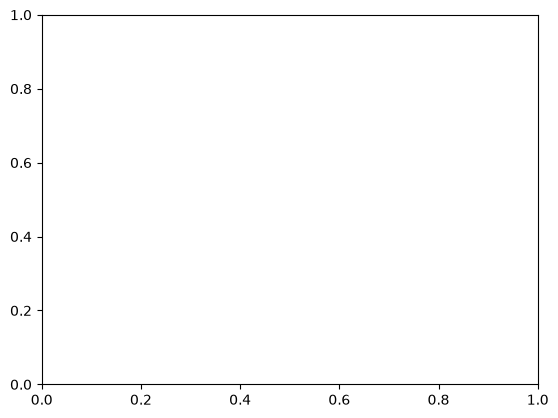

In [19]:
tree_to_check = 2  # picked at random

plot_tree(model, tree_idx=tree_to_check)